In [1]:
# Do not change this cell

import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchinfo import summary
import torch.nn.functional as F

import matplotlib.pyplot as plt
from timeit import default_timer as timer

import numpy as np

random_seed = 1
torch.manual_seed(random_seed)
np.random.seed(random_seed)

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

train_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

trainset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=ToTensor()
)
validationset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=ToTensor()
)
testset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=ToTensor()
)
classes = trainset.classes

valid_size = 0.2
train_length = len(trainset)
indices = list(range(len(trainset)))
split = int(np.floor(valid_size * train_length))

np.random.shuffle(indices)

train_idx=indices[split:]
valid_idx=indices[:split]
train_sampler=SubsetRandomSampler(train_idx)
validation_sampler=SubsetRandomSampler(valid_idx)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, sampler=train_sampler)
valid_loader = DataLoader(trainset, batch_size=batch_size, sampler=validation_sampler)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

print(f"Length of train data loader: {len(train_loader)} batches of {batch_size}")
print(f"Length of validation data loader: {len(valid_loader)} batches of {batch_size}")
print(f"Length of test data loader: {len(test_loader)} batches of {batch_size}")

# Check out what is inside the training data loader
train_features_batch, train_label_batch = next(iter(train_loader))
print(train_features_batch.shape, train_label_batch.shape)

Length of train data loader: 188 batches of 256
Length of validation data loader: 47 batches of 256
Length of test data loader: 40 batches of 256
torch.Size([256, 1, 28, 28]) torch.Size([256])


In [2]:
# Do not change this cell
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

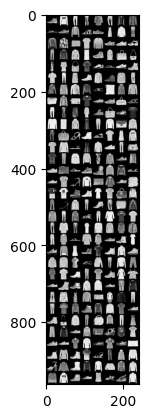

In [3]:
# Do not change this cell
dataiter = iter(test_loader)
images, labels = next(dataiter)
# Show images
imshow(torchvision.utils.make_grid(images))

In [4]:
# TODO: you will design your model here
class ConvModel(nn.Module):
    def __init__(self, input_size, output_size):
        # TODO: complete this method
        super(ConvModel, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc_input_size = 64 * 7 * 7
        self.fc1 = nn.Linear(self.fc_input_size, 128)
        self.fc2 = nn.Linear(128, output_size)

    def forward(self, x):
        # TODO: complete this method
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, self.fc_input_size)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

In [5]:
def train_step(model, train_loader, loss_fn, optimizer, reg_param, device):
    # TODO: implement one epoch of training
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)
        
        # Add L2 regularization if reg_param > 0
        if reg_param > 0:
            l2_reg = sum(torch.norm(param, 2)**2 for param in model.parameters())
            loss += reg_param * l2_reg
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

In [6]:
def evaluation_step(model, data_loader, loss_fn, reg_param, device):
    # TODO: implement evaluation on a data set, data_loader 
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
 
            if reg_param > 0:
                l2_reg = sum(torch.norm(param, 2)**2 for param in model.parameters())
                loss += reg_param * l2_reg
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    avg_loss = total_loss / len(data_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

In [7]:
def train_conv_model(train_loader, valid_loader, test_loader, random_seed):
    # Make device
    device = "cpu"
    if torch.cuda.is_available():
        device = "cuda"
    else:
        if torch.backends.mps.is_available():
            device = "mps"

    torch.manual_seed(random_seed)  # do not change this

    # TODO: write codes to train your model here
    
    input_size = 1  
    output_size = len(classes)  
    model = ConvModel(input_size, output_size).to(device)
    
    loss_fn = nn.CrossEntropyLoss()  
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 
    reg_param = 0.0001  
    
    
    num_epochs = 50
    train_losses, train_accuracies = [], []
    valid_losses, valid_accuracies = [], []
    test_losses, test_accuracies = [], []
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")

        
        train_loss, train_accuracy = train_step(model, train_loader, loss_fn, optimizer, reg_param, device)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        
        
        valid_loss, valid_accuracy = evaluation_step(model, valid_loader, loss_fn, reg_param, device)
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_accuracy)
        
        
        test_loss, test_accuracy = evaluation_step(model, test_loader, loss_fn, reg_param, device)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)
        
        
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")
        print(f"Validation Loss: {valid_loss:.4f}, Validation Accuracy: {valid_accuracy:.2f}%")
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")
    
    
    return model, train_losses, train_accuracies, valid_losses, valid_accuracies, test_losses, test_accuracies

In [8]:
def plot_accuracy_performance(train_accuracies, valid_accuracies, test_accuracies):
   # TODO: plot accuracy curves, you can reuse your codes from the simple classification task 
    epochs = range(1, len(train_accuracies) + 1)
    plt.plot(epochs, train_accuracies, label='Train')
    plt.plot(epochs, valid_accuracies, label='Valid')
    plt.plot(epochs, test_accuracies, label='Test')
        
    plt.xlabel("Iterations")
    plt.ylabel("Accuracy")
    plt.title("Training, Validation, and Test Accuracy Over Iterations")
    plt.legend()
    plt.show()

In [9]:
def plot_loss_performance(train_losses, valid_accuracies, test_losses):
# TODO: plot loss curves, you can reuse your codes from the simple classification task
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, train_losses, label="Train Loss", marker="o", color="blue")
    plt.plot(epochs, valid_losses, label="Validation Loss", marker="s", color="green")  # Fixed here
    plt.plot(epochs, test_losses, label="Test Loss", marker="x", color="red")
    
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.title("Training, Validation, and Test Loss over Iterations")
    plt.legend()
    plt.grid(True)
    
    plt.show()

In [10]:
# Do not change this cell
random_seed = 1
model, train_losses, train_accuracies, valid_losses, valid_accuracies, test_losses, test_accuracies\
= train_conv_model(train_loader, valid_loader, test_loader, random_seed)

Epoch 1/50
Train Loss: 0.6693, Train Accuracy: 76.58%
Validation Loss: 0.4646, Validation Accuracy: 83.88%
Test Loss: 0.4798, Test Accuracy: 83.18%
Epoch 2/50
Train Loss: 0.4045, Train Accuracy: 86.12%
Validation Loss: 0.3795, Validation Accuracy: 87.03%
Test Loss: 0.3979, Test Accuracy: 86.40%
Epoch 3/50
Train Loss: 0.3554, Train Accuracy: 88.03%
Validation Loss: 0.3378, Validation Accuracy: 88.66%
Test Loss: 0.3636, Test Accuracy: 87.69%
Epoch 4/50
Train Loss: 0.3220, Train Accuracy: 89.25%
Validation Loss: 0.3157, Validation Accuracy: 89.38%
Test Loss: 0.3371, Test Accuracy: 88.90%
Epoch 5/50
Train Loss: 0.3083, Train Accuracy: 89.84%
Validation Loss: 0.3261, Validation Accuracy: 88.78%
Test Loss: 0.3494, Test Accuracy: 87.60%
Epoch 6/50
Train Loss: 0.2919, Train Accuracy: 90.44%
Validation Loss: 0.3352, Validation Accuracy: 88.53%
Test Loss: 0.3662, Test Accuracy: 87.57%
Epoch 7/50
Train Loss: 0.2792, Train Accuracy: 90.92%
Validation Loss: 0.3267, Validation Accuracy: 89.03%
Test 

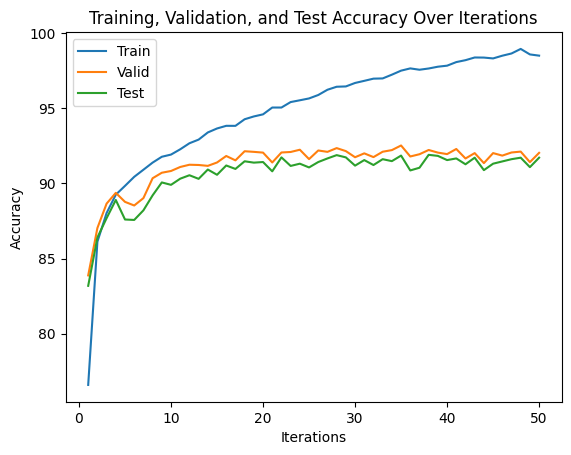

In [11]:
# Do not change this cell
plot_accuracy_performance(train_accuracies, valid_accuracies, test_accuracies)

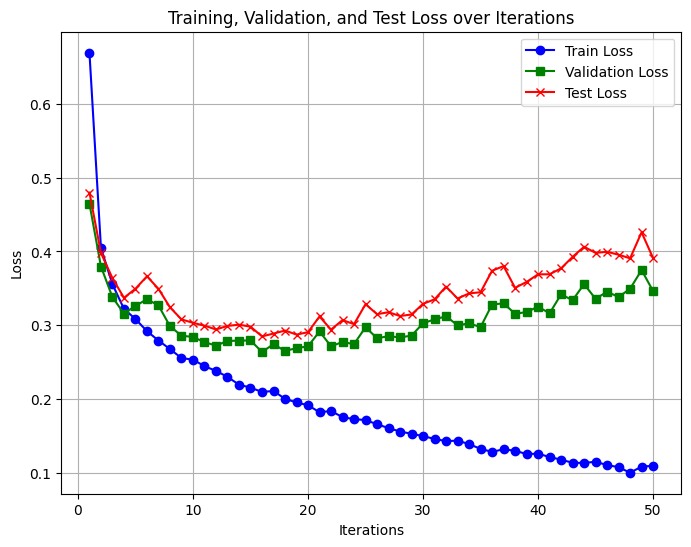

In [12]:
# Do not change this cell
plot_loss_performance(train_losses, valid_losses, test_losses)